In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import statsmodels.api as sm

In [3]:
# 1. Load Real Dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='Target')
data = pd.concat([X, y], axis=1)

print(f"Dataset loaded with {X.shape[1]} features.\n")

Dataset loaded with 30 features.



In [14]:
# --- TECHNIQUE 1: Correlation Analysis ---
correlation = data.corr()['Target'].abs().sort_values(ascending=False)
print("Top 5 Correlated Features:")
print(correlation[1:6]) # Excluding target itself
print("-" * 30)

Top 5 Correlated Features:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
Name: Target, dtype: float64
------------------------------


In [5]:
# --- TECHNIQUE 2: Chi-Square Test ---
# Chi2 requires non-negative values
chi_scores, p_values = chi2(X, y)
chi_df = pd.DataFrame({'Feature': X.columns, 'Chi2 Score': chi_scores, 'p-value': p_values})
print("Top 5 Chi-Square Features:")
print(chi_df.sort_values(by='Chi2 Score', ascending=False).head(5))
print("-" * 30)

Top 5 Chi-Square Features:
            Feature     Chi2 Score  p-value
23       worst area  112598.431564      0.0
3         mean area   53991.655924      0.0
13       area error    8758.504705      0.0
22  worst perimeter    3665.035416      0.0
2    mean perimeter    2011.102864      0.0
------------------------------


In [6]:
# --- TECHNIQUE 3: Forward Selection (Wrapper Method) ---
def forward_selection(X, y):
    selected = []
    remaining = list(X.columns)
    while len(selected) < 5: # Limit to top 5 for brevity
        scores = []
        for feature in remaining:
            model = sm.OLS(y, sm.add_constant(X[selected + [feature]])).fit()
            scores.append((model.rsquared, feature))
        best_score, best_feature = max(scores)
        selected.append(best_feature)
        remaining.remove(best_feature)
    return selected

print("Forward Selection (Top 5):")
print(forward_selection(X, y))
print("-" * 30)

Forward Selection (Top 5):
['worst concave points', 'worst radius', 'worst texture', 'worst area', 'smoothness error']
------------------------------


In [7]:
# --- TECHNIQUE 4: Backward Elimination (Wrapper Method) ---
def backward_elimination(X, y, threshold=0.05):
    X_const = sm.add_constant(X)
    while True:
        model = sm.OLS(y, X_const).fit()
        max_p = model.pvalues.max()
        if max_p > threshold:
            remove_feature = model.pvalues.idxmax()
            X_const = X_const.drop(columns=[remove_feature])
        else:
            break
    return X_const.columns



selected_columns = backward_elimination(X, y)

print("Backward Elimination remaining features count:", len(selected_columns))

print("Selected Feature Names:")
print(list(selected_columns))

print("-" * 30)

Backward Elimination remaining features count: 14
Selected Feature Names:
['const', 'mean radius', 'mean compactness', 'mean concave points', 'radius error', 'smoothness error', 'concavity error', 'concave points error', 'worst radius', 'worst texture', 'worst area', 'worst concavity', 'worst symmetry', 'worst fractal dimension']
------------------------------


In [8]:
# --- TECHNIQUE 5: Lasso Regression (Embedded Method) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lasso = Lasso(alpha=0.01) # alpha controls sparsity
lasso.fit(X_scaled, y)

lasso_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso.coef_})
important_features = lasso_df[lasso_df['Coefficient'] != 0]
print(f"Lasso kept {len(important_features)} features. Top ones:")
print(important_features.sort_values(by='Coefficient', key=abs, ascending=False))
print(important_features.sort_values(by='Coefficient', key=abs, ascending=False).head(5))

Lasso kept 12 features. Top ones:
                   Feature  Coefficient
20            worst radius    -0.166596
27    worst concave points    -0.126911
21           worst texture    -0.051017
7      mean concave points    -0.045709
28          worst symmetry    -0.040223
24        worst smoothness    -0.032805
1             mean texture    -0.019530
10            radius error    -0.018349
9   mean fractal dimension     0.015021
14        smoothness error    -0.009790
26         worst concavity    -0.008220
16         concavity error     0.003305
                 Feature  Coefficient
20          worst radius    -0.166596
27  worst concave points    -0.126911
21         worst texture    -0.051017
7    mean concave points    -0.045709
28        worst symmetry    -0.040223


## Unit 2 practicals P14, P15

Identification of outliers in datasets using statistical methods.

Detection and removal of outliers using Isolation Forest.

1. The Z-Score MethodThe Z-score tells you how many standard deviations a data point is from the mean. A common threshold is 3; any point with a Z-score $> 3$ or $< -3$ is considered an outlier.$$Z = \frac{x - \mu}{\sigma}$$

In [9]:
import numpy as np
import pandas as pd
from scipy import stats

def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]

    print(f"Z-Score Method: Found {len(outliers)} outliers in '{column}'")
    return outliers

# Example usage with Breast Cancer 'mean area'
outliers_z = detect_outliers_zscore(X, 'mean area')

Z-Score Method: Found 8 outliers in 'mean area'


2. The IQR Method (Boxplot Method)The IQR method is more robust because it uses the median and quartiles, which are less affected by extreme values than the mean.Lower Bound: $Q1 - 1.5 \times IQR$Upper Bound: $Q3 + 1.5 \times IQR$

In [10]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"IQR Method: Found {len(outliers)} outliers in '{column}'")
    print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    return outliers

# Example usage
outliers_iqr = detect_outliers_iqr(X, 'mean area')

IQR Method: Found 25 outliers in 'mean area'
Bounds: [-123.30, 1326.30]


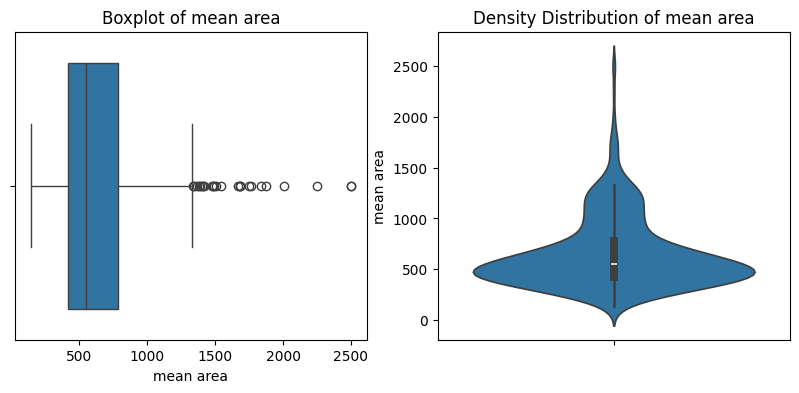

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers(df, column):
    plt.figure(figsize=(10, 4))

    # Subplot 1: Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')

    # Subplot 2: Histogram
    plt.subplot(1, 2, 2)
    sns.violinplot(df[column])
    plt.title(f'Density Distribution of {column}')

    plt.show()

plot_outliers(X, 'mean area')

In [12]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.datasets import load_breast_cancer

# 1. Load your dataset
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
print(f"Original dataset shape: {df.shape}")

# 2. Initialize Isolation Forest
# contamination: the expected proportion of outliers in the data (e.g., 0.05 = 5%)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# 3. Fit and Predict
# Returns 1 for inliers and -1 for outliers
df['anomaly_score'] = iso_forest.fit_predict(df)

# 4. Separate Outliers and Inliers
outliers = df[df['anomaly_score'] == -1]
clean_df = df[df['anomaly_score'] == 1].drop(columns=['anomaly_score'])

print(f"Detected outliers: {len(outliers)}")
print(f"Cleaned dataset shape: {clean_df.shape}")

# 5. (Optional) View the features of the most "extreme" outliers
print("\nSample of detected outliers:")
outliers.head()

Original dataset shape: (569, 30)
Detected outliers: 29
Cleaned dataset shape: (540, 30)

Sample of detected outliers:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,anomaly_score
0,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,-1
3,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,-1
9,12.46,24.04,83.97,475.9,0.11860,0.2396,0.2273,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.2075,-1
12,19.17,24.80,132.40,1123.0,0.09740,0.2458,0.2065,0.11180,0.2397,0.07800,...,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.1767,0.3176,0.1023,-1
42,19.07,24.81,128.30,1104.0,0.09081,0.2190,0.2107,0.09961,0.2310,0.06343,...,33.17,177.40,1651.0,0.1247,0.7444,0.7242,0.2493,0.4670,0.1038,-1


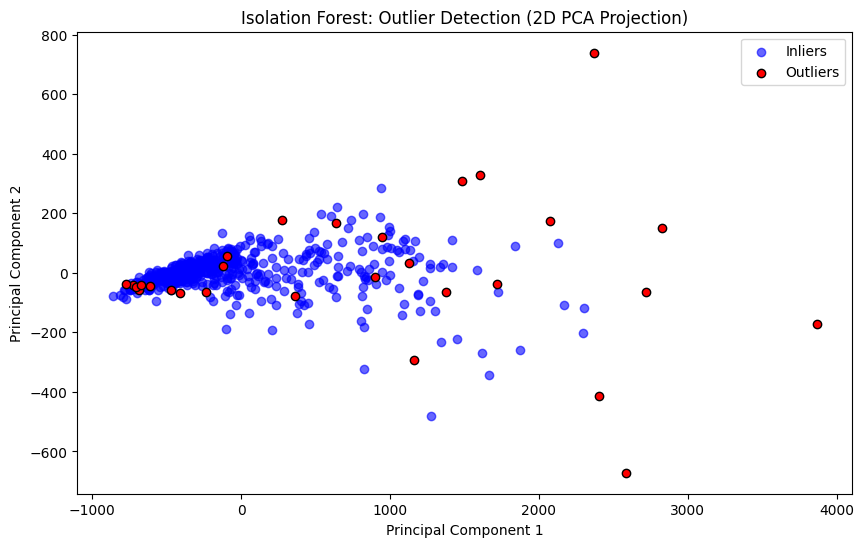

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# 1. Reduce 30 features to 2 features for 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2. Fit Isolation Forest on the reduced data
iso_forest = IsolationForest(contamination=0.05, random_state=42)
preds = iso_forest.fit_predict(X) # Fitting on full 30 features for accuracy

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[preds == 1, 0], X_pca[preds == 1, 1], c='blue', label='Inliers', alpha=0.6)
plt.scatter(X_pca[preds == -1, 0], X_pca[preds == -1, 1], c='red', label='Outliers', edgecolors='k')

plt.title("Isolation Forest: Outlier Detection (2D PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()